Dataset loaded successfully!

 Initial Columns: ['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration', 'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity', 'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit', 'Work_Hours', 'Travel_Time', 'Social_Interactions', 'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection']
<class 'pandas.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  773 non-null    int64  
 1   Gender               773 non-null    str    
 2   Marital_Status       773 non-null    str    
 3   Sleep_Duration       773 non-null    float64
 4   Sleep_Quality        773 non-null    float64
 5   Physical_Activity    773 non-null    float64
 6   Screen_Time          773 non-null    float64
 7   Caffeine_Intake      773 non

C:\Users\aditi\AppData\Local\Temp\ipykernel_24192\1352442700.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to th


 Model Accuracy Comparison:
Logistic Regression: 0.58
Decision Tree: 0.65
Random Forest: 0.73


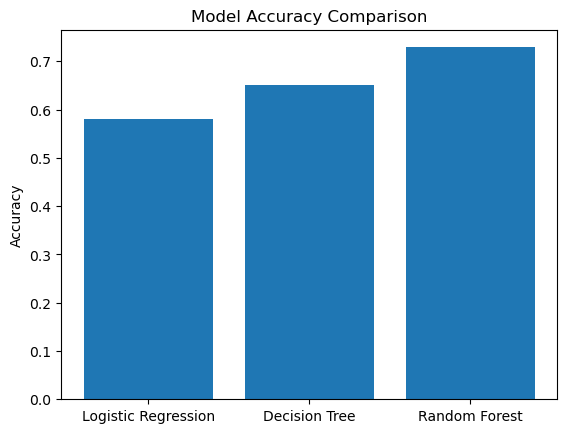


 Best Model: Random Forest

 Enter details to predict stress status:


Enter Age between 18-60:  20
Enter Gender:  Female
Enter Marital_Status(Single,Divorced,Married):  Single
Enter Sleep_Duration(3.5-8):  6
Enter Sleep_Quality(2-5):  3
Enter Physical_Activity(1-5):  2
Enter Screen_Time(2-8):  7
Enter Caffeine_Intake(0-4):  1
Enter Alcohol_Intake(0-2):  0
Enter Smoking_Habit(Yes,No):  No


In [ ]:
# Mental Health & Stress Level Prediction Project
# Concepts: List, Tuple, Set, Dict, String, OOP, Inheritance,
# Exception Handling, NumPy, pandas, Model Building, Visualization

#--Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#--Data Loading with Exception Handling

try:
    df = pd.read_csv("stress_detection_data.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please check the file path.")
except Exception as e:
    print("Error loading file:", e)


#--Data Cleaning and Preprocessing

print("\n Initial Columns:", list(df.columns))

# Drop irrelevant columns
df = df.drop(['Occupation', 'Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level','Exercise_Type','Bed_Time','Wake_Up_Time'], axis=1)

# Handle missing values
df = df.dropna()
print(df.info()) #checking for the datatypes

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Stress_Detection':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode target column
df['Stress_Detection'] = df['Stress_Detection'].map({'High':2,'Medium': 1, 'Low': 0})

print("\n Data Preprocessing Completed!")

# print(df.info()) #ensuring only numerical datatypes are there

# --Using PSC Core Concepts

# List - store column names
col_list = list(df.columns)
print("\n Columns List:", col_list)

# Tuple - store shape info
shape_info = (df.shape[0], df.shape[1])
print("\n Dataset shape (rows, cols):", shape_info)

# Set - find unique values in Stress column
stress_set = set(df['Stress_Detection'])
print("\n Unique values in target column:", stress_set)

# Dictionary - store label encoders
encoder_dict = {col: list(le.classes_) for col, le in label_encoders.items()}
print("\n Encoded categorical mappings:", encoder_dict)

# String Manipulation Example
print("\n Example String Operation:")
sample_str = "stress prediction project"
print("Uppercase:", sample_str.upper())
print("Title Case:", sample_str.title())

#--OOP Concepts
class StressModel:
    """Base class for Stress Prediction Models"""
    def __init__(self, model_name):
        self.model_name = model_name
    
    def train_model(self, X_train, y_train):
        pass  # To be overridden
    
    def evaluate_model(self, X_test, y_test):
        pass

class LogisticStressModel(StressModel):
    """Derived class implementing Logistic Regression"""
    def __init__(self):
        super().__init__("Logistic Regression")
        self.model = LogisticRegression()
    
    def train_model(self, X_train, y_train):
        self.model.fit(X_train, y_train)
    
    def evaluate_model(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        return acc

#--Split Data & Train Models
X = df.drop('Stress_Detection', axis=1)
y = df['Stress_Detection']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train multiple models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy_results[name] = acc

#--Model Comparison
print("\n Model Accuracy Comparison:")
for model_name, acc in accuracy_results.items():
    print(f"{model_name}: {acc:.2f}")

# Visualization
plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

#--Choose Best Model
best_model_name = max(accuracy_results, key=accuracy_results.get)
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name}")


# --User Input for Prediction
print("\n Enter details to predict stress status:")

# user_data = {}
# for col in X.columns:
#     val = input(f"Enter {col}: ")
#     user_data[col] = val
    
# Collecting user input manually for each column
Age = int(input("Enter Age between 18-60: "))
Gender = input("Enter Gender: ")
Marital_Status = input("Enter Marital_Status(Single,Divorced,Married): ")
Sleep_Duration = int(input("Enter Sleep_Duration(3.5-8): "))
Sleep_Quality = int(input("Enter Sleep_Quality(2-5): "))
Physical_Activity = int(input("Enter Physical_Activity(1-5): "))
Screen_Time = int(input("Enter Screen_Time(2-8): "))
Caffeine_Intake = int(input("Enter Caffeine_Intake(0-4): "))
Alcohol_Intake = int(input("Enter Alcohol_Intake(0-2): "))
Smoking_Habit = input("Enter Smoking_Habit(Yes,No): ")
Work_Hours = int(input("Enter Work_Hours(6-14): "))
Travel_Time = int(input("Enter Travel_Time(0.5-5): "))
Social_Interactions = int(input("Enter Social_Interactions(1-5): "))
Meditation_Practice = input("Enter Meditation_Practice(Yes,No): ")

# Create a DataFrame with the input
import pandas as pd

user_df = pd.DataFrame({
    'Age': [Age],
    'Gender': [Gender],
    'Marital_Status': [Marital_Status],
    'Sleep_Duration': [Sleep_Duration],
    'Sleep_Quality': [Sleep_Quality],
    'Physical_Activity': [Physical_Activity],
    'Screen_Time': [Screen_Time],
    'Caffeine_Intake': [Caffeine_Intake],
    'Alcohol_Intake': [Alcohol_Intake],
    'Smoking_Habit': [Smoking_Habit],
    'Work_Hours': [Work_Hours],
    'Travel_Time': [Travel_Time],
    'Social_Interactions': [Social_Interactions],
    'Meditation_Practice': [Meditation_Practice]
})

# Convert user input to DataFrame
# user_df = pd.DataFrame([user_data])

# Apply label encoding to categorical inputs if needed
for col in user_df.columns:
    if col in label_encoders:
        user_df[col] = label_encoders[col].transform(user_df[col])

# Convert numeric columns to float
for col in user_df.columns:
    user_df[col] = pd.to_numeric(user_df[col], errors='coerce')

# Handle missing
user_df = user_df.fillna(0)

# Prediction
prediction = best_model.predict(user_df)
result = "Person is Stressed" if prediction[0] in [1, 2] else "Person is Not Stressed"
print("\n Prediction Result:", result)